### Old Version

In [6]:
##OLD VERSION##
import numpy as  np
from numba import njit
from itertools import product

OPEN = (6, 7, 8)

def actions_from_roll(d1, d2, d3, d4, OPEN):
    """ Returns up to 3 unique actions (dx,dy,dz) from the 3 pairings.
    OPEN must be of length 3. """
    o0, o1, o2 = OPEN
    pairings = ((d1+d2, d3+d4), (d1+d3, d2+d4), (d1+d4, d2+d3))
    acts = set()
    for s1, s2 in pairings:
        dx = (1 if s1 == 6 else 0) + (1 if s2 == 6 else 0)
        dy = (1 if s1 == 7 else 0) + (1 if s2 == 7 else 0)
        dz = (1 if s1 == 8 else 0) + (1 if s2 == 8 else 0)
        if dx + dy + dz > 0:
            acts.add((dx, dy, dz))
    return list(acts)

def precompute_actions(OPEN):
    """ Builds a padded action array of shape (1296, 3, 3) with -1 (because numba requires fixed size arrays). """
    rolls = list(product(range(1, 7), repeat=4))  # 6^4 = 1296 possible rolls with 4 dice
    R = len(rolls)
    Amax = 3
    actions = -np.ones((R, Amax, 3), dtype=np.int8) # size = 1296*3*3

    for r, (d1, d2, d3, d4) in enumerate(rolls):
        acts = actions_from_roll(d1, d2, d3, d4, OPEN)
        for k in range(min(len(acts), Amax)):
            actions[r, k, 0] = acts[k][0]
            actions[r, k, 1] = acts[k][1]
            actions[r, k, 2] = acts[k][2]

    return actions

@njit
def compute_V(Nx, Ny, Nz, actions):
    
    V = np.zeros((Nx + 1, Ny + 1, Nz + 1))
    V[Nx, Ny, Nz] = Nx + Ny + Nz

    Smax = Nx + Ny + Nz
    R = actions.shape[0]
    Amax = actions.shape[1]

    for s in range(Smax - 1, -1, -1):
        # iterates all (x,y,z) with x+y+z = s within bounds
        
        # Nx
        x_min = max(0, s - (Ny + Nz)) # y+z = s-x 
        x_max = min(Nx, s)
        for x in range(x_min, x_max + 1):
            dif = s - x
            y_min = max(0, dif - Nz)
            y_max = min(Ny, dif)
            
            # Ny
            for y in range(y_min, y_max + 1):
                z = dif - y
                if z < 0 or z > Nz:
                    continue
                if x == Nx and y == Ny and z == Nz:
                    continue

                immediate_gain = x + y + z  # if we stop

                # if we keep going
                future_gain = 0.0
                for r in range(R):
                    best = 0.0  # if no admissible action, we get 0
                    for k in range(Amax):
                        dx = actions[r, k, 0]
                        if dx < 0:
                            continue
                        dy = actions[r, k, 1]
                        dz = actions[r, k, 2]
                        nx = x + dx
                        ny = y + dy
                        nz = z + dz
                        if nx <= Nx and ny <= Ny and nz <= Nz: # checks admissibility
                            val = V[nx, ny, nz]
                            if val > best:
                                best = val
                    future_gain += 1/R * best

                V[x, y, z] = immediate_gain if immediate_gain >= future_gain else future_gain

    return V



In [7]:
%%time
N6, N7, N8 = 100, 100, 100
OPEN = (6, 7, 8)
actions = precompute_actions(OPEN)
V = compute_V(N6, N7, N8, actions)
print("Le gain optimal est :", V[0, 0, 0])

Le gain optimal est : 6.330720105660973
CPU times: user 11 s, sys: 72.9 ms, total: 11 s
Wall time: 11.1 s


### New version

In [1]:
## NEW VERSION WITH ACTIONS INSTEAD OF ROLLS ##
import numpy as np
from numba import njit

OPEN = (6, 7, 8)

def compute_probabilities():
    pairs = {}
    for dice1 in range(1,7):
        for dice2 in range(1,7):
            for dice3 in range(1,7):
                for dice4 in range(1,7):
                    couples_get = (
                        tuple(sorted([dice1 + dice2, dice3 + dice4])),
                        tuple(sorted([dice1 + dice3, dice2 + dice4])),
                        tuple(sorted([dice1 + dice4, dice2 + dice3]))
                    )

                    if couples_get not in pairs:
                        pairs[couples_get] = 1/(6**4)
                    else:
                        pairs[couples_get] += 1/(6**4)

    pair_keys = list(pairs.keys())
    R = len(pair_keys)

    pair_array = np.zeros((R,3,2), dtype=np.int8)
    prob_array = np.zeros(R)

    for i,k in enumerate(pair_keys):
        for j in range(3):
            pair_array[i,j,0] = k[j][0]
            pair_array[i,j,1] = k[j][1]
        prob_array[i] = pairs[k]
    #print(pair_array[22])
    return pair_array, prob_array


def actions_from_roll(pairings, OPEN):
    o0, o1, o2 = OPEN
    acts = set()
    for p1, p2 in pairings:
        dx = (1 if p1 == o0 else 0) + (1 if p2 == o0 else 0)
        dy = (1 if p1 == o1 else 0) + (1 if p2 == o1 else 0)
        dz = (1 if p1 == o2 else 0) + (1 if p2 == o2 else 0)

        if dx + dy + dz > 0:
            acts.add((dx, dy, dz))

    return list(acts)


def precompute_actions(OPEN):
    pair_array, prob_array = compute_probabilities()
    R = pair_array.shape[0]
    Amax = 3
    actions = -np.ones((R, Amax, 3), dtype=np.int8)
    for r in range(R):
        pairings = (
            tuple(pair_array[r,0]),
            tuple(pair_array[r,1]),
            tuple(pair_array[r,2])
        )
        acts = actions_from_roll(pairings, OPEN)

        for k in range(min(len(acts), Amax)):
            actions[r,k] = acts[k]
    return actions, pair_array, prob_array


@njit
def compute_V(Nx, Ny, Nz, actions, prob_array, V_max, Wx = 1, Wy = 1, Wz = 1, x_begin=0, y_begin=0, z_begin=0):
    Nx -= x_begin
    Ny -= y_begin
    Nz -= z_begin
    V = np.zeros((Nx + 1, Ny + 1, Nz + 1))
    V[Nx, Ny, Nz] = V_max

    Smax = Nx + Ny + Nz
    R = actions.shape[0]
    Amax = actions.shape[1]
    policy = 1+np.zeros((Nx + 1, Ny + 1, Nz + 1, R, 3), dtype=np.int8)
    stop,continu = 0,0
    for s in range(Smax - 1, -1, -1):
        x_min = max(0, s - (Ny + Nz))
        x_max = min(Nx, s)

        for x in range(x_min, x_max + 1):
            dif = s - x
            y_min = max(0, dif - Nz)
            y_max = min(Ny, dif)

            for y in range(y_min, y_max + 1):
                z = dif - y
                if z < 0 or z > Nz:
                    continue
                if x == Nx and y == Ny and z == Nz:
                    continue
                immediate_gain = Wx*x + Wy*y + Wz*z
                future_gain = 0.0
                for r in range(R):
                    best = 0.0
                    a_best = [-2,-2,-2]
                    for a in range(Amax):
                        dx = actions[r,a,0]
                        if dx < 0:
                            continue
                        dy = actions[r,a,1]
                        dz = actions[r,a,2]
                        nx = x + dx
                        ny = y + dy
                        nz = z + dz
                        val = V[min(nx, Nx), min(ny, Ny), min(nz, Nz)]
                        if val > best:
                            a_best[0] = actions[r,a,0]
                            a_best[1] = actions[r,a,1]
                            a_best[2] = actions[r,a,2]
                            best = val
                    #print(a_best)
                    policy[x, y, z, r, 0] = a_best[0]
                    policy[x, y, z, r, 1] = a_best[1]
                    policy[x, y, z, r, 2] = a_best[2]
                    future_gain += prob_array[r] * best
                if immediate_gain >= future_gain:
                    V[x,y,z] = immediate_gain
                    policy[x, y, z] = -1
                    stop +=1
                else:
                    V[x,y,z] = future_gain
                    continu +=1
    return V, policy

In [4]:
actions, pair_array, prob_array = precompute_actions(OPEN)
prob_chiffres = {}
for i in range(1, 13):
    mask = np.any(pair_array == i, axis=(1, 2))
    prob_chiffres[i] =np.sum(prob_array[mask])  # Probabilité d'obtenir un 6

In [5]:
%%time
N6, N7, N8 = 11, 13, 11
OPEN = (6, 7, 8)
V_max = (prob_chiffres[2]+prob_chiffres[7]+prob_chiffres[11])
V, policy = compute_V(N6, N7, N8, actions, prob_array, 34, x_begin = 0, y_begin = 0, z_begin = 0)
print("Le gain optimal est :", V[0, 0, 0])

Le gain optimal est : 6.330612535094908
CPU times: user 1.09 s, sys: 114 ms, total: 1.21 s
Wall time: 1.56 s


In [6]:
import os 

# Fonctions pour sauvegarder et charger V et policy 
def save_arrays(V, policy, folder="data"):
    if not os.path.exists(folder):
        os.makedirs(folder)
    np.save(os.path.join(folder, "V.npy"), V)
    np.save(os.path.join(folder, "policy.npy"), policy)
    print("V et policy sauvegardés dans", folder)

def load_arrays(folder="data"):
    V_path = os.path.join(folder, "V.npy")
    policy_path = os.path.join(folder, "policy.npy")
    if os.path.exists(V_path) and os.path.exists(policy_path):
        V = np.load(V_path)
        policy = np.load(policy_path)
        print("V et policy chargés depuis", folder)
        return V, policy
    return None, None

### Minimum of rolls

In [12]:
def compute_V_min_roll(Nx, Ny, Nz, actions, prob_array):
    V = np.zeros((Nx + 1, Ny + 1, Nz + 1, Nx + 1, Ny + 1, Nz + 1))
    V[Nx, Ny, Nz, Nx, Ny, Nz] = 0

    Smax = Nx + Ny + Nz
    R = actions.shape[0]
    Amax = actions.shape[1]
    policy = 1+np.zeros((Nx + 1, Ny + 1, Nz + 1, Nx + 1, Ny + 1, Nz + 1, R, 3), dtype=np.int8)
    for s in range(Smax - 1, -1, -1):
        x_min = max(0, s - (Ny + Nz))
        x_max = min(Nx, s)

        for x in range(x_min, x_max + 1):
            dif = s - x
            y_min = max(0, dif - Nz)
            y_max = min(Ny, dif)

            for y in range(y_min, y_max + 1):
                z = dif - y
                if z < 0 or z > Nz:
                    continue
                if x == Nx and y == Ny and z == Nz:
                    continue
                for x_ in range(x, Nx):
                    for y_ in range(y, Ny):
                        for z_ in range(z, Nz):
                            immediate_gain = 1 + V[x_,y_,z_,x,y,z]
                            future_gain = 0.0
                            for r in range(R):
                                best = np.inf
                                a_best = [-2,-2,-2]
                                for a in range(Amax):
                                    dx = actions[r,a,0]
                                    if dx < 0:
                                        continue
                                    dy = actions[r,a,1]
                                    dz = actions[r,a,2]
                                    nx = x + dx
                                    ny = y + dy
                                    nz = z + dz
                                    val = V[min(nx, Nx), min(ny, Ny), min(nz, Nz), x, y, z]
                                    if val < best:
                                        a_best[0] = actions[r,a,0]
                                        a_best[1] = actions[r,a,1]
                                        a_best[2] = actions[r,a,2]
                                        best = val
                                if best == np.inf:
                                    best = 1 + V[x,y,z,x,y,z]
                                #print(a_best)
                                policy[x, y, z, x_, y_, z_, r, 0] = a_best[0]
                                policy[x, y, z, x_, y_, z_, r, 1] = a_best[1]
                                policy[x, y, z, x_, y_, z_, r, 2] = a_best[2]
                                future_gain += prob_array[r] * best
                            if immediate_gain <= future_gain:
                                V[x, y, z, x_, y_, z_] = immediate_gain
                                policy[x, y, z, x_, y_, z_] = -1
                            else:
                                V[x, y, z, x_, y_, z_] = future_gain
    return V, policy

In [13]:
N6, N7, N8 = 11, 13, 11
OPEN = (6, 7, 8)
actions, pair_array, prob_array = precompute_actions(OPEN)
V, policy = compute_V_min_roll(N6, N7, N8, actions, prob_array)
print("Le gain optimal est :", V[0, 0, 0, 0, 0, 0])

Le gain optimal est : 0.08024691358024692


In [9]:
print("Le gain optimal est :", V)

Le gain optimal est : [[[[[[0.         0.         0.         ... 0.         0.
      0.        ]
     [0.         0.         0.         ... 0.         0.
      0.        ]
     [0.         0.         0.         ... 0.         0.
      0.        ]
     ...
     [0.         0.         0.         ... 0.         0.
      0.        ]
     [0.         0.         0.         ... 0.         0.
      0.        ]
     [0.         0.         0.         ... 0.         0.
      0.        ]]

    [[0.         0.         0.         ... 0.         0.
      0.        ]
     [0.         0.16049383 0.16049383 ... 0.16049383 0.16049383
      0.        ]
     [0.         0.16049383 0.16049383 ... 0.16049383 0.16049383
      0.        ]
     ...
     [0.         0.16049383 0.16049383 ... 0.16049383 0.16049383
      0.        ]
     [0.         0.16049383 0.16049383 ... 0.16049383 0.16049383
      0.        ]
     [0.         0.         0.         ... 0.         0.
      0.        ]]

    [[0.         0.     

### Simulation

In [7]:
@njit
def simulation_lancers(n_simu=100, n_manche=50, n_tour=500):
    """Simule N lancers de 4 dés et retourne une liste de tuples (d1,d2,d3,d4)"""
    lancers = []
    for _ in range(n_simu):
        lancer_simu = []
        for _ in range(n_manche):
            lancer_tour = []
            for _ in range(n_tour):
                d1, d2, d3, d4 = np.random.randint(1, 7, size=4)
                lancer_tour.append(((int(d1), int(d2), int(d3), int(d4))))
            lancer_simu.append(lancer_tour)
        lancers.append(lancer_simu)
    return lancers
print(simulation_lancers(10))

[[[(4, 3, 6, 1), (3, 1, 2, 3), (5, 3, 6, 2), (1, 6, 4, 6), (3, 2, 6, 6), (1, 5, 2, 2), (4, 3, 6, 6), (1, 4, 5, 4), (3, 1, 2, 1), (4, 3, 1, 5), (3, 1, 2, 2), (1, 5, 4, 6), (6, 5, 2, 3), (2, 4, 3, 5), (6, 1, 3, 6), (6, 2, 5, 1), (4, 5, 6, 3), (5, 4, 6, 5), (4, 2, 1, 4), (4, 6, 4, 6), (1, 6, 5, 6), (2, 6, 5, 2), (6, 1, 3, 1), (5, 4, 2, 2), (2, 2, 2, 6), (2, 1, 2, 1), (2, 2, 5, 3), (2, 4, 4, 2), (4, 1, 2, 4), (3, 2, 6, 2), (3, 3, 6, 4), (3, 6, 4, 1), (2, 1, 2, 6), (5, 4, 3, 4), (6, 3, 3, 4), (1, 3, 3, 2), (2, 2, 3, 2), (4, 2, 5, 2), (3, 5, 4, 1), (1, 1, 3, 5), (3, 1, 4, 6), (5, 3, 6, 2), (1, 6, 4, 6), (3, 3, 5, 5), (1, 4, 1, 5), (2, 5, 6, 3), (2, 1, 2, 3), (5, 5, 6, 5), (1, 6, 3, 4), (4, 5, 4, 2), (6, 5, 6, 1), (3, 2, 6, 4), (2, 4, 4, 6), (4, 2, 3, 6), (1, 3, 1, 3), (1, 4, 1, 5), (2, 3, 4, 5), (3, 1, 6, 3), (2, 4, 1, 1), (4, 5, 2, 6), (3, 1, 3, 1), (4, 2, 5, 1), (5, 1, 5, 2), (5, 6, 1, 6), (4, 5, 6, 4), (4, 1, 2, 6), (5, 4, 6, 2), (2, 5, 3, 5), (1, 5, 6, 2), (3, 4, 3, 4), (4, 6, 5, 4), (1,

In [8]:
def simulation_player_v_weight(lancers: list[list[tuple[int, int, int, int]]], 
                               Ns:dict[int, int], 
                               actions:np.ndarray, 
                               pair_array: np.ndarray, 
                               col_1, col_2, col_3,
                               prob_chiffres,
                               verbose=False): 
    '''
    Simulate a game by following the optimal policy
    lancers : a list that contains 10000 dices
    Ns : a dictionary the hight of the 3 opens columns
    actions : the precomputed actions for each possible roll
    pair_array : the precomputed pairings for each possible roll'''
    x, y, z = 0, 0, 0
    n_throw = 0
    i = -1
    j = 0
    x_stop, y_stop, z_stop = 0,0,0
    V_max = prob_chiffres[col_1] + prob_chiffres[col_2] + prob_chiffres[col_3]
    _,policy = compute_V(Ns[col_1], Ns[col_2], Ns[col_3], actions, prob_array, V_max, Wx=prob_chiffres[col_1]/Ns[col_1], Wy=prob_chiffres[col_2]/Ns[col_2], Wz=prob_chiffres[col_3]/Ns[col_3])
    while x < Ns[col_1] or y < Ns[col_2] or z < Ns[col_3]: # stop if we finish the game
        i +=1
        #print(n_throw, j,i)
        if i == len(lancers[0]):
            i = 0
        d1, d2, d3, d4 = lancers[j][i]
        pairings = (
            tuple(sorted([d1 + d2, d3 + d4])),
            tuple(sorted([d1 + d3, d2 + d4])),
            tuple(sorted([d1 + d4, d2 + d3]))
        )
        pairings = np.array(pairings, dtype=np.int8)
        r = np.bincount(np.where(np.all(pair_array == pairings, axis=1))[0]).argmax()
        acts = actions[r]
        nb_fail = 0
        for a in range(acts.shape[0]):
            if acts[a,0] < 0: # no action possible for this pairing
                nb_fail += 1
            else:
                if (x == Ns[col_1] and acts[a,1] == 0 and acts[a,2] == 0) or ( # if we finish the line x and no other actions possible
                    y == Ns[col_2] and acts[a,0] == 0 and acts[a,2] == 0) or ( # if we finish the line y and no other actions possible
                    z == Ns[col_3] and acts[a,0] == 0 and acts[a,1] == 0) or ( # if we finish the line z and no other actions possible
                    x == Ns[col_1] and y == Ns[col_2] and acts[a,2] == 0) or ( # if we finish the line x and y and no actions possible for the line z
                    x == Ns[col_1] and z == Ns[col_3] and acts[a,1] == 0) or ( # if we finish the line y and z and no actions possible for the line x
                    y == Ns[col_2] and z == Ns[col_3] and acts[a,0] == 0): # if we finish the line y and z and no actions possible for the line x
                        nb_fail += 1
        if nb_fail == acts.shape[0]:
            if verbose:
                print("No possible action, player loses")
            x, y, z = x_stop, y_stop, z_stop # we lose all we gained since the last stop
            n_throw += 1
            j += 1
            i = -1
            #return 0,0,0
        else:
            lines_moved_on = policy[x-x_stop, y-y_stop, z-z_stop, r]
            x = min(x + lines_moved_on[0], Ns[col_1])  # we can't move beyond the end of the line
            y = min(y + lines_moved_on[1], Ns[col_2])
            z = min(z + lines_moved_on[2], Ns[col_1])
            if verbose:
                print()
                print("Dice rolled:", lancers[i])
                print("Pairings:", pairings.tolist())
                print("Chosen action:", lines_moved_on.tolist())
                print("Current position:", (int(x), int(y), int(z)))

            if policy[x-x_stop, y-y_stop, z-z_stop, 0, 0] == -1: # the player decides to stop
                if verbose:
                    print("Player decides to stop at:", (int(x), int(y), int(z)))
                x_stop, y_stop, z_stop = int(x), int(y), int(z)
                if Ns[col_1]-x_stop !=0:
                    weight_1 = prob_chiffres[col_1]/(Ns[col_1]-x_stop)
                else:
                    weight_1 = 1
                if Ns[col_2]-y_stop !=0:
                    weight_2 = prob_chiffres[col_2]/(Ns[col_2]-y_stop)
                else:
                    weight_2 = 1
                if Ns[col_3]-z_stop !=0:
                    weight_3 = prob_chiffres[col_3]/(Ns[col_3]-z_stop)
                else:
                    weight_3 = 1
                _,policy = compute_V(Ns[col_1], Ns[col_2], Ns[col_3], actions, prob_array, V_max, Wx=weight_1, Wy=weight_2, Wz=weight_3, x_begin=x_stop, y_begin=y_stop, z_begin=z_stop)
                n_throw += 1
                j += 1
                i = -1
            if (x == Ns[col_1] or y== Ns[col_2] or z == Ns[col_3]) and (x != x_stop or y != y_stop or z != z_stop):
                if x == Ns[col_1] and x != x_stop:
                    x_stop = x 
                if y == Ns[col_2] and y != y_stop:
                    y_stop = y
                if z == Ns[col_3] and z != z_stop:
                    z_stop = z
                if Ns[col_1]-x_stop !=0:
                    weight_1 = prob_chiffres[col_1]/(Ns[col_1]-x_stop)
                else:
                    weight_1 = 1
                if Ns[col_2]-y_stop !=0:
                    weight_2 = prob_chiffres[col_2]/(Ns[col_2]-y_stop)
                else:
                    weight_2 = 1
                if Ns[col_3]-z_stop !=0:
                    weight_3 = prob_chiffres[col_3]/(Ns[col_3]-z_stop)
                else:
                    weight_3 = 1
                _,policy = compute_V(Ns[col_1], Ns[col_2], Ns[col_3], actions, prob_array, V_max, Wx=weight_1, Wy=weight_2, Wz=weight_3, x_begin=x_stop, y_begin=y_stop, z_begin=z_stop)
    return n_throw

In [9]:
def simulation_player_v1(lancers: list[list[tuple[int, int, int, int]]], 
                         Ns:dict[int, int], 
                         actions:np.ndarray, 
                         pair_array: np.ndarray,
                         col_1, col_2, col_3,
                         verbose=False): 
    '''
    Simulate a game by following the optimal policy
    lancers : a list that contains 10000 dices
    Ns : a dictionary the hight of the 3 opens columns
    actions : the precomputed actions for each possible roll
    pair_array : the precomputed pairings for each possible roll'''
    x, y, z = 0, 0, 0
    n_throw = 0
    i = -1
    j = 0
    x_stop, y_stop, z_stop = 0,0,0
    V_max = Ns[col_3] + Ns[col_1] + Ns[col_2]
    _,policy = compute_V(Ns[col_1], Ns[col_2], Ns[col_3], actions, prob_array, V_max)
    while x < Ns[col_1] or y < Ns[col_2] or z < Ns[col_3]: # stop if we finish the game
        i +=1
        #print(n_throw, j,i)
        if i == len(lancers[0]):
            i = 0
        if j == len(lancers):
            j=0
        d1, d2, d3, d4 = lancers[j][i]
        pairings = (
            tuple(sorted([d1 + d2, d3 + d4])),
            tuple(sorted([d1 + d3, d2 + d4])),
            tuple(sorted([d1 + d4, d2 + d3]))
        )
        pairings = np.array(pairings, dtype=np.int8)
        r = np.bincount(np.where(np.all(pair_array == pairings, axis=1))[0]).argmax()
        acts = actions[r]
        nb_fail = 0
        for a in range(acts.shape[0]):
            if acts[a,0] < 0: # no action possible for this pairing
                nb_fail += 1
            else:
                if (x == Ns[col_1] and acts[a,1] == 0 and acts[a,2] == 0) or ( # if we finish the line x and no other actions possible
                    y == Ns[col_2] and acts[a,0] == 0 and acts[a,2] == 0) or ( # if we finish the line y and no other actions possible
                    z == Ns[col_3] and acts[a,0] == 0 and acts[a,1] == 0) or ( # if we finish the line z and no other actions possible
                    x == Ns[col_1] and y == Ns[col_2] and acts[a,2] == 0) or ( # if we finish the line x and y and no actions possible for the line z
                    x == Ns[col_1] and z == Ns[col_3] and acts[a,1] == 0) or ( # if we finish the line y and z and no actions possible for the line x
                    y == Ns[col_2] and z == Ns[col_3] and acts[a,0] == 0): # if we finish the line y and z and no actions possible for the line x
                        nb_fail += 1
        if nb_fail == acts.shape[0]:
            if verbose:
                print("No possible action, player loses")
            x, y, z = x_stop, y_stop, z_stop # we lose all we gained since the last stop
            n_throw += 1
            j += 1
            i = -1
            #return 0,0,0
        else:
            lines_moved_on = policy[x-x_stop, y-y_stop, z-z_stop, r]
            x = min(x + lines_moved_on[0], Ns[col_1])  # we can't move beyond the end of the line
            y = min(y + lines_moved_on[1], Ns[col_2])
            z = min(z + lines_moved_on[2], Ns[col_3])
            if verbose:
                print()
                print("Dice rolled:", lancers[i])
                print("Pairings:", pairings.tolist())
                print("Chosen action:", lines_moved_on.tolist())
                print("Current position:", (int(x), int(y), int(z)))

            if policy[x-x_stop, y-y_stop, z-z_stop, 0, 0] == -1: # the player decides to stop
                if verbose:
                    print("Player decides to stop at:", (int(x), int(y), int(z)))
                x_stop, y_stop, z_stop = int(x), int(y), int(z)
                _,policy = compute_V(Ns[col_1], Ns[col_2], Ns[col_3], actions, prob_array, V_max, x_begin=x_stop, y_begin=y_stop, z_begin=z_stop)
                n_throw += 1
                j += 1
                i = -1
            if (x == Ns[col_1] or y== Ns[col_2] or z == Ns[col_3]) and (x != x_stop or y != y_stop or z != z_stop):
                if x == Ns[col_1] and x != x_stop:
                    x_stop = x 
                if y == Ns[col_2] and y != y_stop:
                    y_stop = y
                if z == Ns[col_3] and z != z_stop:
                    z_stop = z
                _,policy = compute_V(Ns[col_1], Ns[col_2], Ns[col_3], actions, prob_array, V_max, x_begin=x_stop, y_begin=y_stop, z_begin=z_stop)
    return n_throw

In [10]:
V, policy = load_arrays()
Ns = {6: 11, 7: 13, 8: 11}   # nombre de cases par colonne (à adapter)
if V is None or policy is None:
    print("Calcul de V et policy...")
    V, policy = compute_V(Ns, actions, prob_array)
    save_arrays(V, policy)

V et policy chargés depuis data


In [11]:
n_simu = 1000
lancers = simulation_lancers(n_simu = n_simu, n_manche=200, n_tour=200)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

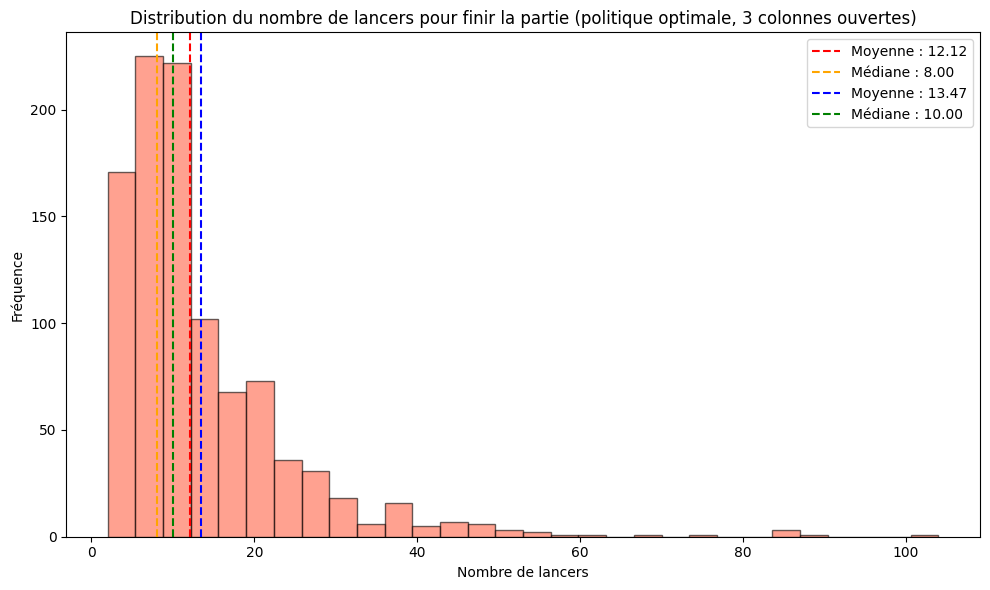

In [13]:
n_weight = []
n = []
Ns = {6: 11, 7: 13, 8: 11}
for k in range(n_simu):
    print(k)
    n_ = simulation_player_v_weight(lancers[k], Ns, actions, pair_array, 6, 7, 8, prob_chiffres, False)
    n__ = simulation_player_v1(lancers[k], Ns, actions, pair_array, 6, 7, 8, False)
    #print(n)
    n_weight.append(n_)
    n.append(n__)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
#plt.hist(n, bins=30, edgecolor='black', color='steelblue', alpha=0.6)
plt.hist(n_weight, bins=30, edgecolor='black', color='tomato', alpha=0.6)

plt.axvline(np.mean(n), color='red', linestyle='--', linewidth=1.5, label=f'Moyenne : {np.mean(n):.2f}')
plt.axvline(np.median(n), color='orange', linestyle='--', linewidth=1.5, label=f'Médiane : {np.median(n):.2f}')

plt.axvline(np.mean(n_weight), color='blue', linestyle='--', linewidth=1.5, label=f'Moyenne : {np.mean(n_weight):.2f}')
plt.axvline(np.median(n_weight), color='green', linestyle='--', linewidth=1.5, label=f'Médiane : {np.median(n_weight):.2f}')

plt.xlabel("Nombre de lancers")
plt.ylabel("Fréquence")
plt.title("Distribution du nombre de lancers pour finir la partie (politique optimale, 3 colonnes ouvertes)")
plt.legend()
plt.tight_layout()
plt.show()


### Monte Carlo

In [ ]:
def estimate_expected_gain(num_simulations, policy, actions, pair_array):
    total_gain = 0
    for _ in range(num_simulations):
        lancers = simulation_lancers(100)  # 100 rolls per simulation
        x, y, z = simulation_player(lancers, policy, actions, pair_array)
        total_gain += x + y + z
    return total_gain / num_simulations

# Run the simulation
num_simulations = 1000
expected_gain_sim = estimate_expected_gain(num_simulations, policy, actions, pair_array)
expected_gain_theoretical = V[0,0,0]

print(f"Estimated expected gain over {num_simulations} simulations: {expected_gain_sim:.2f}")
print(f"Theoretical expected gain from V[0,0,0]: {expected_gain_theoretical:.2f}")

TypeError: simulation_player() missing 2 required positional arguments: 'actions' and 'pair_array'

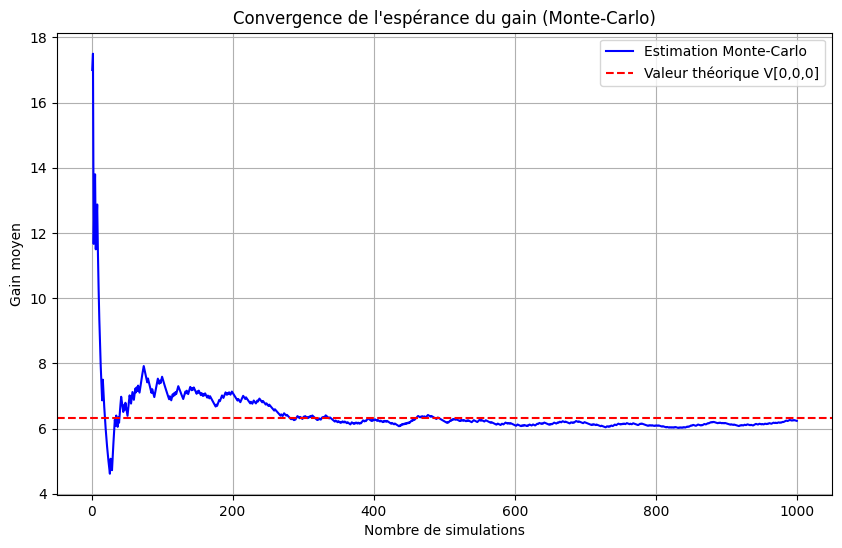

In [ ]:
import matplotlib.pyplot as plt

def monte_carlo_with_plot(num_simulations, policy, actions, pair_array, V):
    gains = []
    cumulative_mean = []

    for i in range(1, num_simulations+1):
        lancers = simulation_lancers(100)
        x, y, z = simulation_player(lancers, policy, actions, pair_array, verbose=False)
        gain = x + y + z
        gains.append(gain)
        cumulative_mean.append(np.mean(gains))  # moyenne cumulative

    # Tracé
    plt.figure(figsize=(10,6))
    plt.plot(range(1, num_simulations+1), cumulative_mean, label="Estimation Monte-Carlo", color="blue")
    plt.axhline(y=V[0,0,0], color="red", linestyle="--", label="Valeur théorique V[0,0,0]")
    plt.xlabel("Nombre de simulations")
    plt.ylabel("Gain moyen")
    plt.title("Convergence de l'espérance du gain (Monte-Carlo)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return cumulative_mean

cumulative_mean = monte_carlo_with_plot(1000, policy, actions, pair_array, V)

### Heuristic one dimension

In [17]:
import numpy as np
from numba import njit

OPEN = 7


def actions_from_roll_one_dimensional(pairings: list[tuple[int, int]], OPEN: int) -> list[int]:
    """ 
    Compute the possible actions (dx) from the 3 pairings, given the OPEN column:
    Stay, move 1 time, move 2 times. 
    """
    o = OPEN
    acts = set()
    for p1, p2 in pairings:
        dx = (1 if p1 == o else 0) + (1 if p2 == o else 0)
        if dx > 0:
            acts.add(dx)
    return list(acts)


def precompute_actions_one_dimensional(OPEN: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Builds a padded action array of shape (1296, 3) with -1 (because numba requires fixed size arrays).
    Each action is an integer in {0,1,2} representing how many times we can move on the line corresponding to OPEN."""
    pair_array, prob_array = compute_probabilities()
    R = pair_array.shape[0]
    Amax = 3 # max 3 actions possible (move 1, move 2, or stay)
    actions = -np.ones((R, Amax), dtype=np.int8)
    for r in range(R):
        pairings = (
            tuple(pair_array[r,0]),
            tuple(pair_array[r,1]),
            tuple(pair_array[r,2])
        )
        acts = actions_from_roll_one_dimensional(pairings, OPEN)
        if r==22:
            print(pairings, acts)

        for k in range(min(len(acts), Amax)):
            actions[r,k] = acts[k]
    return actions, pair_array, prob_array


@njit
def compute_V_one_dimensional(Nx: int, actions: np.ndarray, prob_array: np.ndarray):

    V = np.zeros(Nx + 1)
    V[Nx] = Nx
    policy = -np.ones((Nx + 1, actions.shape[0]), dtype=np.int8)
    stop, continu = 0, 0

    for x in range(Nx - 1, -1, -1):
        immediate_gain = x # if we stop
        future_gain = 0.0 
        for r in range(actions.shape[0]):
            best = 0.0
            a_best = -1 # if no admissible action, we lose and get 0
            for a in range(actions.shape[1]):
                dx = actions[r,a]
                if dx < 0: 
                    continue # no action for this roll
                nx = min(x + dx, Nx) # next state if we take this action (capped at Nx)
                val = V[nx] 
                if val > best: # we want to maximize our gain
                    best = val
                    a_best = dx
            policy[x, r] = a_best # store the best action for this state and roll
            future_gain += prob_array[r] * best # expected future gain if we keep going

        if immediate_gain >= future_gain: # we should stop
            V[x] = immediate_gain
            policy[x] = -1
            stop += 1
        else: # we should keep going
            V[x] = future_gain
            continu += 1

    return V, policy


In [21]:
def simulation_player_heuristic(lancers, 
                                  actions_3d, pair_array_3d, prob_array_3d,
                                  actions_1d, pair_array_1d, prob_array_1d,
                                  OPEN, alpha, Ns,
                                  verbose=False):

    policies_1d = {}
    for col in OPEN:
        _, pol_1d = compute_V_one_dimensional(Ns[col], actions_1d[col], prob_array_1d[col])
        policies_1d[col] = pol_1d
    _, policy_3d = compute_V(Ns[OPEN[0]], Ns[OPEN[1]], Ns[OPEN[2]], actions_3d, prob_array_3d)
    n_throws = 0
    o0, o1, o2 = OPEN
    x, y, z = 0, 0, 0   # positions actuelles sur chaque colonne
    x_stop, y_stop, z_stop = 0, 0, 0 # positions au dernier stop
    i = -1
    j = 0
    while x < Ns[OPEN[0]] or y < Ns[OPEN[1]] or z < Ns[OPEN[2]]:
        i += 1
        if i >= len(lancers[0]):
            i=0
        lancer = lancers[j][i]
        d1, d2, d3, d4 = lancer

        # --- calcul du pairing et de l'index r (commun aux deux phases) ---
        pairings = np.array([
            sorted([d1+d2, d3+d4]),
            sorted([d1+d3, d2+d4]),
            sorted([d1+d4, d2+d3])
        ], dtype=np.int8)
        r = np.where(np.all(pair_array_3d == pairings, axis=(1,2)))[0]
        if len(r) == 0:
            if verbose: print("Pairing introuvable")
            x, y, z = x_stop, y_stop, z_stop # we lose all we gained since the last stop
            n_throws += 1
            j += 1
            continue
        r = r[0]

        # --- cases restantes par colonne ---
        rem0 = Ns[o0] - x
        rem1 = Ns[o1] - y
        rem2 = Ns[o2] - z

        # --- détection d'une colonne presque remplie ---
        almost = None
        if   (rem0 <= alpha and rem0 > 0): almost = (0, o0, x)
        elif (rem1 <= alpha and rem1 > 0): almost = (1, o1, y)
        elif (rem2 <= alpha and rem2 > 0): almost = (2, o2, z)
        if almost is not None:
            # --- PHASE 2 : policy 1D sur la colonne presque remplie ---
            idx, col, pos = almost
            acts_1d = actions_1d[col]
            pol_1d  = policies_1d[col]

            # vérifie qu'il existe au moins une action admissible
            nb_fail = np.sum(acts_1d[r] < 0)
            if nb_fail == acts_1d.shape[1]:
                if verbose: print("Phase 2 — aucune action possible, le joueur perd")
                x, y, z = x_stop, y_stop, z_stop # we lose all we gained since the last stop
                n_throws += 1
                continue
            dx = pol_1d[pos, r]

            if pol_1d[pos, 0] == -1:
                # la policy 1D dit de s'arrêter
                new_pos = max(pos, pos + acts_1d[r, 0])
                
                if idx == 0: 
                    x = new_pos
                    colo = x
                elif idx==1: 
                    y = new_pos
                    colo = y
                else: 
                    z = new_pos
                    colo = z
                x_stop, y_stop, z_stop = x, y, z
                n_throws += 1
                if verbose: print(f"dé: {lancer}, Phase 2 — stop sur colonne {col} en position {pos}, pos→({x},{y},{z})")
                if colo == Ns[col]:
                    _,policy_3d = compute_V(Ns[OPEN[0]], Ns[OPEN[1]], Ns[OPEN[2]], actions, prob_array, x_stop, y_stop, z_stop)
                else:
                    _,policies_1d[idx] = compute_V_one_dimensional(Ns[col]-colo, actions_1d[col], prob_array_1d[col])
                continue
            
            new_pos = pos + dx
            if idx == 0: x = new_pos
            elif idx == 1: y = new_pos
            else:          z = new_pos

            if verbose:
                print(f"Phase 2 — dé: {lancer}, colonne {col}, dx={dx}, pos→{new_pos}")

            # colonne complétée ?
            if new_pos >= Ns[col]:
                if verbose: print(f"Colonne {col} complétée !")
                if idx == 0: x = Ns[col]
                elif idx == 1: y = Ns[col]
                else:          z = Ns[col]
                x_stop, y_stop, z_stop = x, y, z
                _,policy_3d = compute_V(Ns[OPEN[0]], Ns[OPEN[1]], Ns[OPEN[2]], actions, prob_array, x_stop, y_stop, z_stop)
                j += 1
                n_throws += 1
                continue

        else:
            # --- PHASE 1 : policy 3D ---
            acts_3d = actions_3d[r]
            nb_fail = np.sum(acts_3d[:, 0] < 0)
            if nb_fail == acts_3d.shape[0]:
                if verbose: print("Phase 1 — aucune action possible, le joueur perd")
                x, y, z = x_stop, y_stop, z_stop # we lose all we gained since the last stop
                n_throws += 1
                continue
            nb_fail = 0
            for a in range(acts_3d.shape[0]):
                if acts_3d[a,0] < 0: # no action possible for this pairing
                    nb_fail += 1
                else:
                    if (x == Ns[OPEN[0]] and acts_3d[a,1] == 0 and acts_3d[a,2] == 0) or ( # if we finish the line x and no other actions possible
                        y == Ns[OPEN[1]] and acts_3d[a,0] == 0 and acts_3d[a,2] == 0) or ( # if we finish the line y and no other actions possible
                        z == Ns[OPEN[2]] and acts_3d[a,0] == 0 and acts_3d[a,1] == 0) or ( # if we finish the line z and no other actions possible
                        x == Ns[OPEN[0]] and y == Ns[OPEN[1]] and acts_3d[a,2] == 0) or ( # if we finish the line x and y and no actions possible for the line z
                        x == Ns[OPEN[0]] and z == Ns[OPEN[2]] and acts_3d[a,1] == 0) or ( # if we finish the line y and z and no actions possible for the line x
                        y == Ns[OPEN[1]] and z == Ns[OPEN[2]] and acts_3d[a,0] == 0): # if we finish the line y and z and no actions possible for the line x
                            nb_fail += 1
            if nb_fail == acts_3d.shape[0]:
                if verbose: print("Phase 1 — aucune action possible, le joueur perd")
                x, y, z = x_stop, y_stop, z_stop # we lose all we gained since the last stop
                n_throws += 1
                continue
            lines_moved = policy_3d[x-x_stop, y-y_stop, z-z_stop, r]

            if lines_moved[0] == -1:
                # la policy 3D dit de s'arrêter
                if verbose: print(f"Phase 1 — stop en ({x},{y},{z})")
                x_stop, y_stop, z_stop = x, y, z
                n_throws += 1
                _,policy_3d = compute_V(Ns[OPEN[0]], Ns[OPEN[1]], Ns[OPEN[2]], actions, prob_array, x_stop, y_stop, z_stop)
                j += 1
                continue
            x = min(x + lines_moved[0], Ns[OPEN[0]])  # we can't move beyond the end of the line
            y = min(y + lines_moved[1], Ns[OPEN[1]])
            z = min(z + lines_moved[2], Ns[OPEN[2]])

            if verbose:
                print(f"Phase 1 — dé: {lancer}, action: {lines_moved.tolist()}, pos→({x},{y},{z})")
            if (x == Ns[OPEN[0]] or y== Ns[OPEN[1]] or z == Ns[OPEN[2]]) and (x != x_stop or y != y_stop or z != z_stop):
                if x == Ns[OPEN[0]] and x != x_stop:
                    x_stop = x 
                if y == Ns[OPEN[1]] and y != y_stop:
                    y_stop = y
                if z == Ns[OPEN[2]] and z != z_stop:
                    z_stop = z
                _,policy_3d = compute_V(Ns[OPEN[0]], Ns[OPEN[1]], Ns[OPEN[2]], actions, prob_array, x_stop, y_stop, z_stop)
                j += 1
    
    return n_throws

In [19]:
# Précalcul à faire une fois avant la simulation
Ns = {6: 11, 7: 13, 8: 11}   # nombre de cases par colonne (à adapter)
OPEN = (6, 7, 8)

policies_1d = {}
actions_1d_dict = {}
prob_array_1d = {}
for col in OPEN:
    acts, pair_arr, prob_arr = precompute_actions_one_dimensional(col)
    V, pol = compute_V_one_dimensional(Ns[col], acts, prob_arr)
    policies_1d[col] = pol
    actions_1d_dict[col] = acts
    prob_array_1d[col] = prob_arr

# Précalcul 3D
actions_3d, pair_array_3d, prob_array_3d = precompute_actions(OPEN)
V_3d, policy_3d = compute_V(Ns[6], Ns[7], Ns[8], actions_3d, prob_array_3d)

((np.int8(3), np.int8(4)), (np.int8(2), np.int8(5)), (np.int8(3), np.int8(4))) []
((np.int8(3), np.int8(4)), (np.int8(2), np.int8(5)), (np.int8(3), np.int8(4))) []
((np.int8(3), np.int8(4)), (np.int8(2), np.int8(5)), (np.int8(3), np.int8(4))) []


In [22]:
n_opt_list = []
n_heuristic_list = []

for k in range(n_simu):
    n_opt = simulation_player_v1(lancers[k], Ns, actions, pair_array, False)
    n_heuristic = simulation_player_heuristic(
            lancers[k],
            actions_3d, pair_array_3d, prob_array_3d,
            actions_1d_dict, pair_array_3d, prob_array_1d,
            OPEN, 1, Ns, False
        )
    n_opt_list.append(n_opt)
    n_heuristic_list.append(n_heuristic)

print("numbers of throws to finish the game with the optimal policy when 3 columns are open : ", np.mean(n_opt_list))
print("numbers of throws to finish the game with the heuristic policy when 3 columns are open : ", np.mean(n_heuristic_list))

# Histogramme comparatif
plt.figure(figsize=(10, 6))
plt.hist(n_opt_list, bins=30, edgecolor='black', color='steelblue', alpha=0.6, label='Politique optimale')
plt.hist(n_heuristic_list, bins=30, edgecolor='black', color='tomato', alpha=0.6, label='Politique heuristique')

plt.axvline(np.mean(n_opt_list), color='blue', linestyle='--', linewidth=1.5, label=f'Moyenne optimale : {np.mean(n_opt_list):.2f}')
plt.axvline(np.mean(n_heuristic_list), color='red', linestyle='--', linewidth=1.5, label=f'Moyenne heuristique : {np.mean(n_heuristic_list):.2f}')

plt.xlabel("Nombre de lancers")
plt.ylabel("Fréquence")
plt.title("Distribution du nombre de lancers (politique optimale vs heuristique, 3 colonnes ouvertes)")
plt.legend()
plt.tight_layout()
plt.show()

: 

### Little heuristic

In [9]:
from math import copysign
def heuristic_simple(Ns, lancers, actions, pair_array, n = 5, verbose=False):
    '''We stop every $n$ rolls'''
    n_round = 0
    x, y, z = 0,0,0
    x_stop, y_stop, z_stop = 0, 0, 0
    j = -1
    while x < Ns[6] or y < Ns[7] or z < Ns[8]:
        dice = -1
        j += 1
        for _ in range(n):
            dice +=1
            d1, d2, d3, d4 = lancers[j][dice]
            pairings = (
                tuple(sorted([d1 + d2, d3 + d4])),
                tuple(sorted([d1 + d3, d2 + d4])),
                tuple(sorted([d1 + d4, d2 + d3]))
            )
            pairings = np.array(pairings, dtype=np.int8)
            r = np.bincount(np.where(np.all(pair_array == pairings, axis=1))[0]).argmax()
            acts = actions[r]
            nb_fail = 0
            for a in range(acts.shape[0]):
                if acts[a,0] < 0: # no action possible for this pairing
                    nb_fail += 1
                else:
                    if (x == Ns[6] and acts[a,1] == 0 and acts[a,2] == 0) or ( # if we finish the line x and no other actions possible
                        y == Ns[7] and acts[a,0] == 0 and acts[a,2] == 0) or ( # if we finish the line y and no other actions possible
                        z == Ns[8] and acts[a,0] == 0 and acts[a,1] == 0) or ( # if we finish the line z and no other actions possible
                        x == Ns[6] and y == Ns[7] and acts[a,2] == 0) or ( # if we finish the line x and y and no actions possible for the line z
                        x == Ns[6] and z == Ns[8] and acts[a,1] == 0) or ( # if we finish the line y and z and no actions possible for the line x
                        y == Ns[7] and z == Ns[8] and acts[a,0] == 0): # if we finish the line y and z and no actions possible for the line x
                            nb_fail += 1
            if nb_fail == acts.shape[0]:
                if verbose:
                    print("No possible action, player loses")
                    print(d1,d2,d3,d4)
                    print()
                x, y, z = x_stop, y_stop, z_stop # we lose all we gained since the last stop
                n_round += 1
                j += 1
                break
            else:
                # on choisit l'action qui avance le plus sur la ligne la plus avancée
                best_score = -1
                best_action = None
                for a in range(acts.shape[0]):
                    if acts[a,0] < 0:
                        continue
                    score = 0
                    if x + acts[a,0] > x:
                        score += copysign(1, acts[a,0]) * acts[a,0]**2 
                    if y + acts[a,1] > y:
                        score += copysign(1, acts[a,1]) * acts[a,1]**2 
                    if z + acts[a,2] > z:
                        score += copysign(1, acts[a,2]) * acts[a,2]**2 
                    if score > best_score:
                        best_score = score
                        best_action = acts[a]
                dx, dy, dz = best_action
                x = min(x + dx, Ns[6])
                y = min(y + dy, Ns[7])
                z = min(z + dz, Ns[8])
                if verbose:
                    print(f"Round {n_round}, dice: {d1,d2,d3,d4}, action: {best_action}, pos→({x},{y},{z})")
                if (x == Ns[6] or y== Ns[7] or z == Ns[8]) and (x != x_stop or y != y_stop or z != z_stop):
                    if x == Ns[6] and x != x_stop:
                        x_stop = x 
                    if y == Ns[7] and y != y_stop:
                        y_stop = y
                    if z == Ns[8] and z != z_stop:
                        z_stop = z
        n_round += 1
        x_stop, y_stop, z_stop = x, y, z # on s'arrête à la fin de chaque round
        if verbose:
            print(f"End of round {n_round}, pos: ({x},{y},{z}), stop pos: ({x_stop},{y_stop},{z_stop})")
    return n_round
            

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
numbers of throws to finish the game with the simple heuristic policy when 3 columns are open :  [42.57 30.84 27.69 30.07 32.58 34.56 46.05 58.12 70.71 70.76]


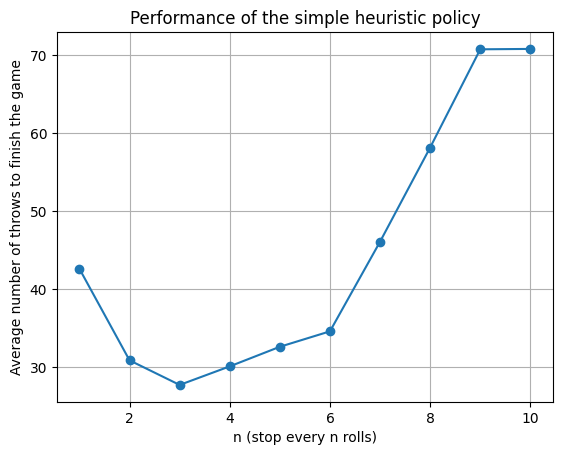

In [34]:
n_moy_heuristic_simple = np.zeros(10)
for k in range(n_simu):
    print(k)
    for n in range(1, 11):
        n_heuristic_simple = heuristic_simple(Ns, lancers[k], actions, pair_array, n=n, verbose=False)
        n_moy_heuristic_simple[n-1] += n_heuristic_simple/n_simu
print("numbers of throws to finish the game with the simple heuristic policy when 3 columns are open : ", n_moy_heuristic_simple)
fig, ax = plt.subplots()
ax.plot(range(1, 11), n_moy_heuristic_simple, marker='o')
ax.set_xlabel('n (stop every n rolls)')
ax.set_ylabel('Average number of throws to finish the game')
ax.set_title('Performance of the simple heuristic policy')
ax.grid()
plt.show()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

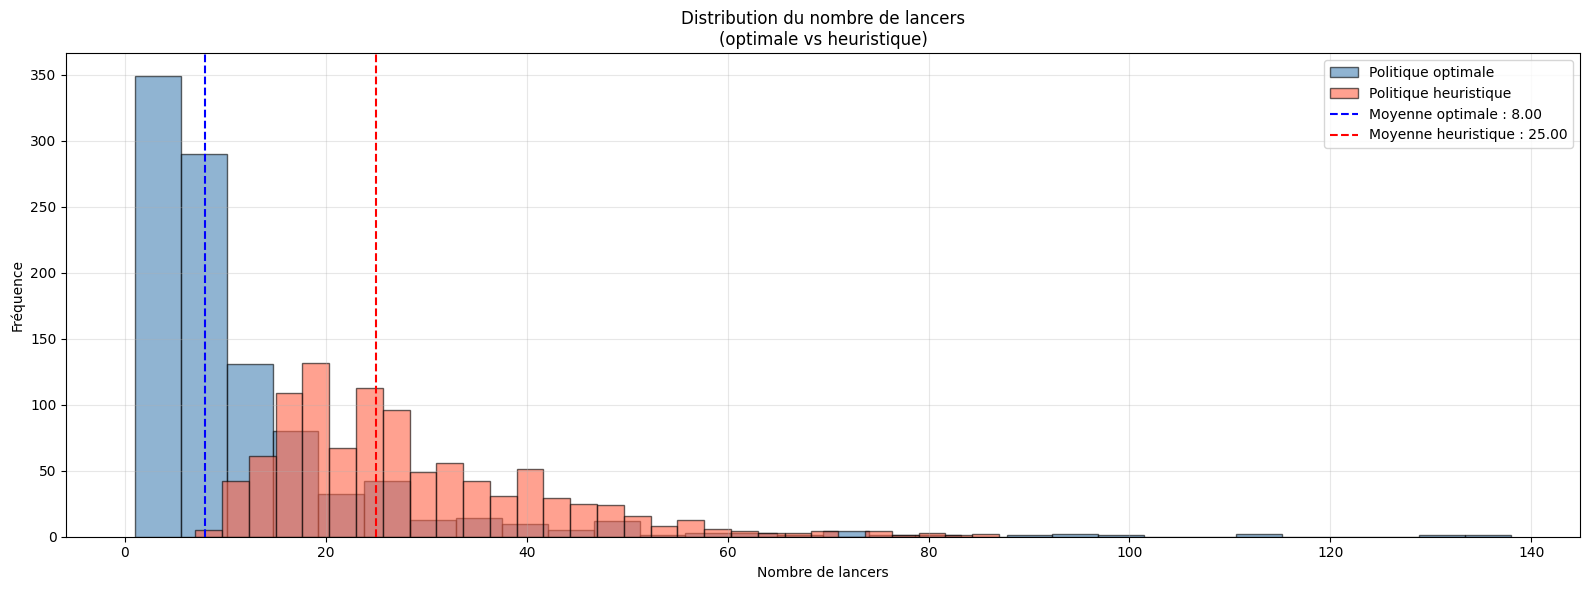

In [ ]:
import matplotlib.pyplot as plt
n_heuristic_simple_list = []
n_opt_list = []
n_heuristic_list = []
for k in range(n_simu):
    print(k)
    n_opt = simulation_player_v1(lancers[k], Ns, actions, pair_array, False)
    n_opt_list.append(n_opt)
    
    n_heuristic_list = simulation_player_heuristic(lancers[k], )

    # Heuristique simple pour chaque n=3
    n_heuristic_simple = heuristic_simple(Ns, lancers[k], actions, pair_array, n=3, verbose=False)
    n_heuristic_simple_list.append(n_heuristic_simple)

n_moy = np.mean(n_heuristic_simple_list)
print("Simple heuristic policy :", n_moy)

# Histogramme comparatif
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# -- Graphe 1 : histogramme optimal vs heuristique
ax.hist(n_opt_list, bins=30, edgecolor='black', color='steelblue', alpha=0.6, label='Politique optimale')
ax.hist(n_heuristic_simple_list, bins=30, edgecolor='black', color='tomato', alpha=0.6, label='Politique heuristique')
ax.axvline(np.median(n_opt_list), color='blue', linestyle='--', linewidth=1.5, label=f'Moyenne optimale : {np.median(n_opt_list):.2f}')
ax.axvline(np.median(n_heuristic_simple_list), color='red', linestyle='--', linewidth=1.5, label=f'Moyenne heuristique : {np.median(n_heuristic_simple_list):.2f}')
ax.set_xlabel('Nombre de lancers')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution du nombre de lancers\n(optimale vs heuristique)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()